In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub
path = kagglehub.dataset_download("rjmanoj/credit-card-customer-churn-prediction")
print(path)

Using Colab cache for faster access to the 'credit-card-customer-churn-prediction' dataset.
/kaggle/input/credit-card-customer-churn-prediction


In [ ]:
import pandas as pd
df = pd.read_csv('/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [ ]:
df.shape

(10000, 14)

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
#Tell us if we have duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
#Customers left the bank, 1 will tell about those who have exited and 0 who hasn't exited
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [ ]:
#Categories in Geography Column
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [ ]:
#Categories in Gender Column
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [ ]:
#Now we will drop first three columns, (Inplace=True will make the changes Permanent)
df.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)

In [ ]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.shape

(10000, 11)

In [ ]:
#One hot Encoding creates N Categorical Columns, (drop_first=True : Drop the first category column and keep only N−1 columns)
# pd.get_dummies(df, columns=['Geography','Gender'],drop_first=True).astype(int) #Comes as true/false so astype will convert into int
df=pd.get_dummies(df, columns=['Geography','Gender'],drop_first=True, dtype=int)

In [ ]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [ ]:
#Drop temporarily last column and store remaining in X, also take the Exited column in y which is our actual output
X = df.drop(columns=['Exited'])
y = df['Exited']

In [ ]:
X,y

(      CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
 0             619   42       2       0.00              1          1   
 1             608   41       1   83807.86              1          0   
 2             502   42       8  159660.80              3          1   
 3             699   39       1       0.00              2          0   
 4             850   43       2  125510.82              1          1   
 ...           ...  ...     ...        ...            ...        ...   
 9995          771   39       5       0.00              2          1   
 9996          516   35      10   57369.61              1          1   
 9997          709   36       7       0.00              1          0   
 9998          772   42       3   75075.31              2          1   
 9999          792   28       4  130142.79              1          1   
 
       IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
 0                  1        101348.88                  

In [ ]:
#split the dataset into train and test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=1)

In [ ]:
X_train.shape,X_test.shape,y_train.shape, y_test.shape

((8000, 11), (2000, 11), (8000,), (2000,))

In [ ]:
#Scaled the values becouse if you don't Neural Networks weights values will not converge fast
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [ ]:
X_test_scaled

array([[-1.03768121,  0.77498705, -1.0482813 , ..., -0.58312392,
        -0.57273139,  0.91509065],
       [ 0.30708683, -0.46686456, -0.70174202, ..., -0.58312392,
        -0.57273139,  0.91509065],
       [-1.23422423,  0.29735181, -1.0482813 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       ...,
       [-0.86182692, -0.46686456,  1.72403288, ..., -0.58312392,
         1.74601919,  0.91509065],
       [-0.30323097, -0.84897275, -1.0482813 , ...,  1.71490137,
        -0.57273139, -1.09278791],
       [ 0.04847759,  1.25262228,  1.3774936 , ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [ ]:
import tensorflow  #Deep learning framework developed by Google
from tensorflow import keras  #Keras = User-friendly wrapper over TensorFlow, which is TensorFlowe’s high-level API.
from tensorflow.keras import Sequential  #model class, stack of layers
from tensorflow.keras.layers import Dense #Every neuron is connected to every neuron in the previous layer (fully connected layer)

In [ ]:
model = Sequential()
#creates a hidden layer
# model.add(Dense(3, activation='sigmoid', input_dim=11)) # 3 neurons, dataset has 11 features, sigmoid → output ∈ (0,1),
# model.add(Dense(1,activation='sigmoid')) #Output layer

model.add(Dense(11, activation='relu', input_dim=11)) # 11 neurons, dataset has 11 features, Relu=used in hidden layers
model.add(Dense(11, activation='relu'))   # 11 neurons, Rectified Linear Unit=used in hidden layers - f(x)=max(0,x)
model.add(Dense(1,activation='sigmoid')) #Output layer

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Number of parameters (weights + biases)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Loss function → what to minimize, Optimizer → how to change weights(Optional)
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [ ]:
# model.fit(X_train_scaled,y_train, epochs=10)

history = model.fit(X_train_scaled,y_train, epochs=100, validation_split=0.2) #8000-20% train, 20%validation

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6989 - loss: 0.6106 - val_accuracy: 0.7975 - val_loss: 0.4884
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7936 - loss: 0.4723 - val_accuracy: 0.8056 - val_loss: 0.4440
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8041 - loss: 0.4460 - val_accuracy: 0.8150 - val_loss: 0.4247
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8172 - loss: 0.4152 - val_accuracy: 0.8231 - val_loss: 0.4099
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8335 - loss: 0.4057 - val_accuracy: 0.8381 - val_loss: 0.3919
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8337 - loss: 0.3921 - val_accuracy: 0.8444 - val_loss: 0.3764
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8491 - loss: 0.3707 - val_accuracy: 0.8506 - val_loss: 0.3652
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8577 - loss: 0.3591 - val_accu

In [ ]:
#get_weights() - returns all trainable parameters of that layer as NumPy arrays, [array_of_weights, array_of_biases]
# model.layers[0].get_weights()  #weights(11*3)+biases(3)=36

model.layers[0].get_weights()  #weights(11*11)+biases(11)=132

[array([[ 0.26295045, -0.07597392, -0.13081695,  0.16726942, -0.06778239,
         -0.19763158,  0.44638062, -0.31042734,  0.03831789,  0.36172947,
         -0.1449501 ],
        [ 0.3298398 ,  0.6550234 , -0.9363777 , -0.49234506,  0.8486691 ,
          0.3250938 ,  0.1164974 ,  0.44548348, -0.9693818 ,  0.20971934,
         -0.6513518 ],
        [-0.0861951 ,  0.02172549,  0.0018232 , -0.34582603,  0.08828873,
          0.40027258, -0.22947286,  0.2652917 , -0.10666237,  0.12937757,
          0.32236028],
        [ 0.2519074 , -0.10597036,  0.12909245,  0.16043422, -0.26682785,
         -0.11070779,  0.5384255 , -0.39825925, -0.5964091 , -0.5886653 ,
          0.14180203],
        [-0.20716389, -0.70434254,  0.00838538,  0.6023358 ,  1.383947  ,
          1.0271974 ,  0.20438895, -0.34915859, -0.00325785,  0.01510154,
         -0.48339126],
        [ 0.2129482 , -0.05725823, -0.2862372 , -0.31664973,  0.15419807,
          0.02589235,  0.16949953, -0.05028717,  0.1959941 ,  0.0916310

In [ ]:
# model.layers[1].get_weights() #weights(3*1)+biases(1)=4

model.layers[1].get_weights() #weights(11*11)+biases(11)=132

[array([[ 1.74880996e-01, -2.62038887e-01,  1.70591772e-01,
          3.30612242e-01, -1.01391411e+00,  2.05268394e-02,
         -2.09940076e-02, -1.34752631e-01,  2.55815089e-01,
          3.26119989e-01,  9.77021083e-02],
        [ 3.51891667e-01,  4.53698814e-01, -7.10574150e-01,
         -9.75255668e-02,  3.44401181e-01, -8.20567846e-01,
         -2.04520464e-01,  3.86253417e-01, -2.27401797e-02,
         -1.31352514e-01, -1.11380197e-01],
        [ 3.24414462e-01,  2.85686664e-02,  4.52858090e-01,
          4.67334688e-01, -2.75339305e-01, -2.23445803e-01,
          3.55814933e-03, -3.72832209e-01,  6.77747667e-01,
          6.71238303e-01,  5.94282858e-02],
        [-1.47035256e-01, -1.92072317e-01,  2.12416217e-01,
          4.01729465e-01, -9.38014805e-01,  1.56433493e-01,
          5.08389354e-01, -1.11672930e-01,  4.80682552e-01,
         -3.66299361e-01,  1.50015228e-03],
        [-1.32574654e+00, -1.65216887e+00,  4.36556906e-01,
          4.42197949e-01, -2.37877056e-01, -

In [ ]:
model.layers[2].get_weights() #weights(11*1)+biases(1)=12

[array([[ 0.78066146],
        [ 0.53956133],
        [ 0.7699422 ],
        [-0.1562532 ],
        [ 1.6850017 ],
        [-0.4433626 ],
        [ 1.3205172 ],
        [ 0.9605124 ],
        [-0.44717926],
        [-0.5645514 ],
        [-0.5483764 ]], dtype=float32),
 array([-0.29705814], dtype=float32)]

In [ ]:
#since we are using sigmoid, so it will give probabilites in output, we store it in y_pred
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
#we take a threashold(0.5 here), so that we convert the predicted output in 0 and 1
import numpy as np
y_pred = np.where(y_log>0.5, 1, 0)  #np.where(condition, value_if_true, value_if_false)

In [ ]:
#model accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)  #compare actual output data with predicted ouput data

0.8545

In [ ]:
import matplotlib.pyplot as plt

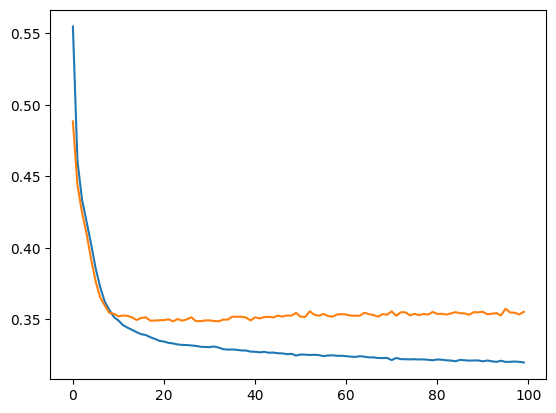

In [ ]:
#training loss decrease faster than validation loss
plt.plot(history.history['loss']) # training loss blue
plt.plot(history.history['val_loss']) #validation loss yellow

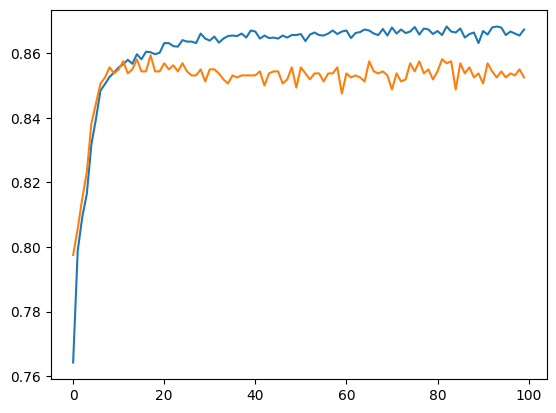

In [ ]:
plt.plot(history.history['accuracy'])  # blue
plt.plot(history.history['val_accuracy']) # yellow